In [ ]:
# This program is for the book "Digital Image Processing" by Dr. Mahmood Azimi-Sadjadi.
# Copyright Copyright (c) 2026 Yifan Yang and Dr. Mahmood Azimi-Sadjadi.
# Contact: mahmood.azimi-sadjadi@colostate.edu

# Give colab access to google drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


245 24
123.60375595092773
2298.096107261241


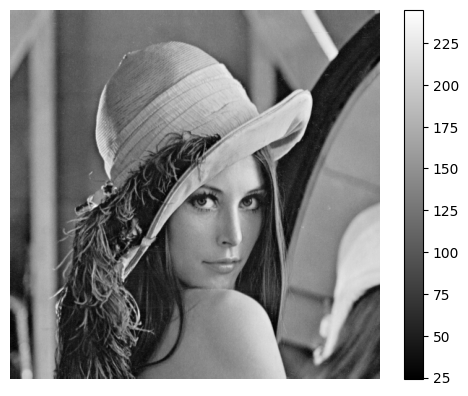

In [ ]:
import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt

# image path
work_path = '/content/drive/MyDrive/DigitalImageProcessing/'

# load image
img = sio.loadmat(work_path + 'Data/lena.mat')['lena']
print(img.max(), img.min())
#img=img/img.max()
img_mean = np.mean(img)
print(img_mean)
print(np.var(img))
# plot image
plt.imshow(img,cmap='gray')
plt.colorbar()
plt.axis('off');

2298.0961072668524


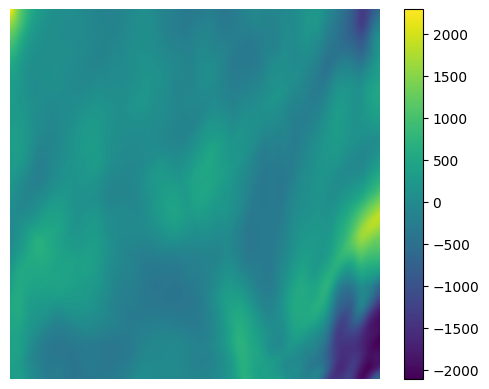

In [ ]:
import numpy as np

def acf2d(k, l):
    total = 0.0
    count = 0

    m_start = max(0, k)
    m_end = min(512, 512 + k)

    n_start = max(0, l)
    n_end = min(512, 512 + l)

    for m in range(m_start, m_end):
        for n in range(n_start, n_end):
            total += (img[m, n] - img_mean) * (img[m - k, n - l] - img_mean)
            count += 1

    if count == 0:
        # If no valid overlapping region (e.g., k or l is too large), return 0.0
        return 0.0
    else:
        return total / count

print(acf2d(0, 0))

acf_img = np.zeros((512, 512))
for i in range(512):
    for j in range(512):
        acf_img[i, j] = acf2d(i, j)

plt.imshow(acf_img, cmap='viridis')
plt.colorbar()
plt.axis('off');

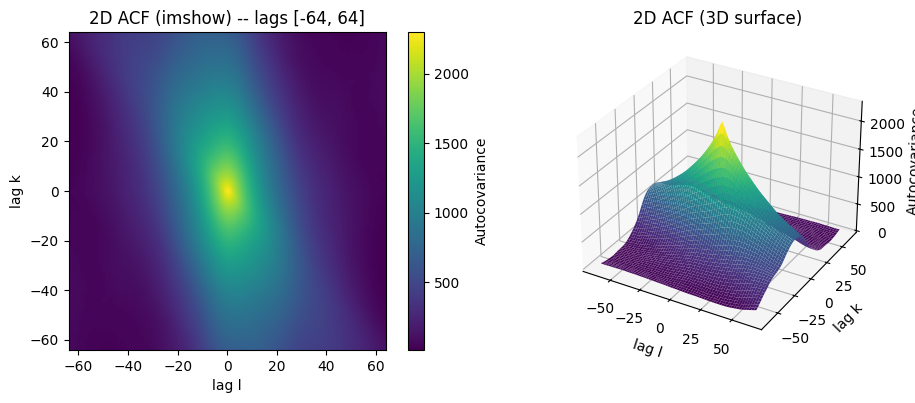

Symmetry check on full ACF (centered array):
  max abs difference between ACF(k,l) and ACF(-k,-l): 1.368e+02
  mean abs difference: 6.284e+00
  relative max difference (norm by max abs ACF): 5.951e-02
lag (k=0, l=0): acf_fft = 2.298096e+03, acf_direct = 2.298096e+03, diff = -5.612e-09
lag (k=10, l=5): acf_fft = 1.606822e+03, acf_direct = 1.659269e+03, diff = -5.245e+01
lag (k=-20, l=15): acf_fft = 1.183393e+03, acf_direct = 1.280233e+03, diff = -9.684e+01


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # registers 3D projection

# If you already have img and img_mean in your environment these lines will be skipped.
# Otherwise we create a representative synthetic image (512x512) for demonstration.
try:
    img  # referenced to check existence
except NameError:
    # synthetic image with spatial structure + noise so the ACF is visible
    N = 512
    x = np.linspace(0, 4 * np.pi, N)
    X, Y = np.meshgrid(x, x)
    img = np.sin(3 * X) + np.cos(5 * Y) + 0.2 * np.random.randn(N, N)

img = np.asarray(img, dtype=float)
img_mean = img.mean()


def acf2d_direct(k, l, img=img, img_mean=img_mean):
    """Direct implementation similar to the function you posted.
    Returns the autocovariance for a single lag (k, l).
    (This is for reference / validation; we won't call it for every lag.)"""
    total = 0.0
    count = 0

    m_start = max(0, k)
    m_end = min(img.shape[0], img.shape[0] + k)

    n_start = max(0, l)
    n_end = min(img.shape[1], img.shape[1] + l)

    for m in range(m_start, m_end):
        for n in range(n_start, n_end):
            total += (img[m, n] - img_mean) * (img[m - k, n - l] - img_mean)
            count += 1

    if count == 0:
        return 0.0
    else:
        return total / count


def acf2d_fft(img):
    """Compute 2D autocovariance (biased, normalized by overlap counts) via FFT.
    Returns an array with zero lag centered (fftshifted)."""
    img = np.asarray(img, dtype=float)
    mean = img.mean()
    f = np.fft.fft2(img - mean)
    ps = np.abs(f) ** 2
    ac = np.fft.ifft2(ps).real  # cross-correlation result, zero-lag at [0,0]
    ac = np.fft.fftshift(ac)    # move zero-lag to center

    # denominator = number of overlapping pixels for every lag (via convolution of ones)
    ones = np.ones_like(img)
    fones = np.fft.fft2(ones)
    denom = np.fft.ifft2(np.abs(fones) ** 2).real
    denom = np.fft.fftshift(denom)

    # avoid division by zero (shouldn't happen for finite image sizes)
    denom[denom == 0] = np.nan
    ac_norm = ac / denom
    return ac_norm


# Compute full autocovariance (centered)
acf_full = acf2d_fft(img)

# Choose a plotting window of lags (for visibility). Use +/- maxlag around center.
maxlag = 64
N0, N1 = img.shape
center0 = N0 // 2
center1 = N1 // 2
sl0 = slice(center0 - maxlag, center0 + maxlag + 1)
sl1 = slice(center1 - maxlag, center1 + maxlag + 1)
acf_sub = acf_full[sl0, sl1]

# lags for meshgrid (k, l)
lags = np.arange(-maxlag, maxlag + 1)
K, L = np.meshgrid(lags, lags, indexing='ij')

# --- Plotting ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(acf_sub, extent=[-maxlag, maxlag, -maxlag, maxlag], origin='lower', cmap='viridis')
plt.colorbar(label='Autocovariance')
plt.title('2D ACF (imshow) -- lags [-%d, %d]' % (maxlag, maxlag))
plt.xlabel('lag l')
plt.ylabel('lag k')

ax = plt.subplot(1, 2, 2, projection='3d')
# downsample for 3D surface plotting to keep it responsive
ds = 2
ax.plot_surface(K[::ds, ::ds], L[::ds, ::ds], acf_sub[::ds, ::ds], cmap='viridis', rcount=80, ccount=80)
ax.set_xlabel('lag l')
ax.set_ylabel('lag k')
ax.set_zlabel('Autocovariance')
ax.set_title('2D ACF (3D surface)')

plt.tight_layout()
plt.show()

# --- Symmetry check ---
# For true autocovariance we expect ACF(k, l) == ACF(-k, -l).
# With fftshifted array, check equality with flip on both axes.
acf_flipped = np.flip(np.flip(acf_full, axis=0), axis=1)  # or np.flip(acf_full)
diff = acf_full - acf_flipped
max_abs_diff = np.nanmax(np.abs(diff))
mean_abs_diff = np.nanmean(np.abs(diff))
rel_max = max_abs_diff / (np.nanmax(np.abs(acf_full)) + 1e-16)

print("Symmetry check on full ACF (centered array):")
print(f"  max abs difference between ACF(k,l) and ACF(-k,-l): {max_abs_diff:.3e}")
print(f"  mean abs difference: {mean_abs_diff:.3e}")
print(f"  relative max difference (norm by max abs ACF): {rel_max:.3e}")

# Also check a few individual lags vs your direct function for validation
for (k, l) in [(0, 0), (10, 5), (-20, 15)]:
    # index into fftshifted array: center + k, center + l
    i = center0 + k
    j = center1 + l
    val_fft = acf_full[i, j]
    val_direct = acf2d_direct(k, l, img=img, img_mean=img_mean)
    print(f"lag (k={k}, l={l}): acf_fft = {val_fft:.6e}, acf_direct = {val_direct:.6e}, diff = {val_fft - val_direct:.3e}")

# Calculate Cov and Define functions


In [ ]:
def get_pho_k(M, k):
    tmp_list = list(range(0, -2 * M -1, -1))
    re = np.zeros((2*M+1, 2*M+1))

    for i in range(2*M+1):
        for j in range(2*M+1):
            # re[i, j] = xg[tmp_list[j] + i, k]
            re[i, j] = acf2d(tmp_list[j] + i, k)
    return re


def get_pho_0_p(M):
    tmp_list = list(range(0, -M-1, -1))

    re = np.zeros((M+1, M+1))
    for i in range(M+1):
        for j in range(M+1):
            # re[i, j] = xg[tmp_list[j] + i, 0]
            re[i, j] = acf2d(tmp_list[j] + i, 0)
    return re


def get_pho_minus_k_p(M, k):
    tmp_list = list(range(M, -M -1, -1))
    re = np.zeros((M+1, 2*M+1))

    for i in range(M+1):
        for j in range(2*M+1):
            # re[i, j] = xg[tmp_list[j] + i, -k]
            re[i, j] = acf2d(tmp_list[j] + i, -k)
    return re

# Adding a comment to ensure this cell is re-evaluated and picks up the latest acf2d definition.


In [ ]:
# @title Causal (1,1)
M=1
pho_0_p = get_pho_0_p(M)
pho_0 = get_pho_k(M, k=0)
pho_minus_1_p = get_pho_minus_k_p(M, k=1)
pho_minus_1_n= get_pho_minus_k_p(M, k=-1)
R = np.block([[pho_0_p, pho_minus_1_p],
              [pho_minus_1_n.T, pho_0]])

iR = np.linalg.inv(R)
sigma2 = 1 / iR[0, 0]
print('sigma^2: ', sigma2)

print("n=0")
for m in [1]:
    print('a(m,n)=(',m,', 0 ): ', -iR[m,0]* sigma2)

print("n=1")
for m in [-1,0,1]:
    kl =(M+1) + m + M
    print('a(m,n)=(',m,', 1 ): ', -iR[kl,0]* sigma2)


sigma^2:  42.82934044229143
n=0
a(m,n)=( 1 , 0 ):  0.6744965941452106
n=1
a(m,n)=( -1 , 1 ):  0.15107090006781224
a(m,n)=( 0 , 1 ):  0.32807083234336026
a(m,n)=( 1 , 1 ):  -0.15495679951808825


In [ ]:
# @title Causal (2,2)
M=2
pho_0_p = get_pho_0_p(M)
pho_0 = get_pho_k(M, k=0)

pho_mins_1 = get_pho_k(M, k=-1)
pho_1 = get_pho_k(M, k=1)


pho_minus_1_p = get_pho_minus_k_p(M, k=1)
pho_minus_2_p = get_pho_minus_k_p(M, k=2)

R = np.block([[pho_0_p, pho_minus_1_p, pho_minus_2_p],
              [pho_minus_1_p.T, pho_0, pho_mins_1],
              [pho_minus_2_p.T, pho_1, pho_0]])

iR = np.linalg.inv(R)
sigma2 = 1 / iR[0, 0]
print('sigma^2: ', sigma2)

print("n=0")
for m in [1, 2]:
    print('a(m,n)=(',m,', 0 ): ', -iR[m,0]* sigma2)

print("n=1")
for m in [-2,-1,0,1, 2]:
    kl =(2 * M + 1) + m
    print('a(m,n)=(',m,', 1 ): ', -iR[kl,0]* sigma2)

print("n=2")
for m in [-2, -1,0,1, 2]:
    kl =2 * (2 * M + 1) + m
    print('a(m,n)=(',m,', 2 ): ', -iR[kl,1]* sigma2)

sigma^2:  100.50117568646878
n=0
a(m,n)=( 1 , 0 ):  1.2260279356686166
a(m,n)=( 2 , 0 ):  -0.5652188852398267
n=1
a(m,n)=( -2 , 1 ):  0.15815581975211984
a(m,n)=( -1 , 1 ):  0.03370591284971095
a(m,n)=( 0 , 1 ):  -0.17458347918671432
a(m,n)=( 1 , 1 ):  0.24896688094233496
a(m,n)=( 2 , 1 ):  -0.043881351578726836
n=2
a(m,n)=( -2 , 2 ):  -0.0739256313852555
a(m,n)=( -1 , 2 ):  -0.09169075554009698
a(m,n)=( 0 , 2 ):  0.5124962057393739
a(m,n)=( 1 , 2 ):  -0.7432094113772397
a(m,n)=( 2 , 2 ):  0.30716092658729904


In [ ]:
# @title Semicausal (1,1)
M=1
pho_0 = get_pho_k(M, k=0)
pho_mins_1 = get_pho_k(M, k=-1)
pho_1 = get_pho_k(M, k=1)

R = np.block([[pho_0, pho_mins_1],
              [pho_1, pho_0]])

iR = np.linalg.inv(R)
sigma2 = 1 / iR[M, M]
print('sigma^2: ', sigma2)

for m in [-1, 0, 1]:
    for n in [0, 1]:
        kl = n * (2 * M + 1) + m + M
        print('a(m,n)=(',m,',',n, '): ', -iR[kl,M]* sigma2)

sigma^2:  51.13064383464997
a(m,n)=( -1 , 0 ):  0.5352828045591661
a(m,n)=( -1 , 1 ):  0.015552219469762596
a(m,n)=( 0 , 0 ):  -1.0
a(m,n)=( 0 , 1 ):  -0.06343207195728524
a(m,n)=( 1 , 0 ):  0.5577134637656882
a(m,n)=( 1 , 1 ):  -0.034324083087740924


In [ ]:
# @title Semicausal (2,2)
M=2
pho_0 = get_pho_k(M, k=0)
pho_mins_1 = get_pho_k(M, k=-1)
pho_mins_2 = get_pho_k(M, k=-2)

pho_1 = get_pho_k(M, k=1)
pho_2 = get_pho_k(M, k=2)

R = np.block([[pho_0, pho_mins_1,pho_mins_2],
              [pho_1, pho_0,pho_mins_1],
              [pho_2, pho_1,pho_0]])

iR = np.linalg.inv(R)
sigma2 = 1 / iR[M, M]
print('sigma^2: ', sigma2)

for m in [-2, -1, 0, 1, 2]:
    for n in [0, 1, 2]:
        kl = n * (2 * M + 1) + m + M
        print('a(m,n)=(',m,',',n, '): ', -iR[kl,M]* sigma2)


sigma^2:  21.692181939816546
a(m,n)=( -2 , 0 ):  -0.2369716469719492
a(m,n)=( -2 , 1 ):  -0.06295703861875115
a(m,n)=( -2 , 2 ):  -0.0879071314517484
a(m,n)=( -1 , 0 ):  0.7225706687021325
a(m,n)=( -1 , 1 ):  0.20422638981060298
a(m,n)=( -1 , 2 ):  0.2525215048154991
a(m,n)=( 0 , 0 ):  -1.0
a(m,n)=( 0 , 1 ):  -0.26098480910441296
a(m,n)=( 0 , 2 ):  -0.2954807681371824
a(m,n)=( 1 , 0 ):  0.7319796743415049
a(m,n)=( 1 , 1 ):  0.2014483458616953
a(m,n)=( 1 , 2 ):  0.1820006628655708
a(m,n)=( 2 , 0 ):  -0.25087824622015525
a(m,n)=( 2 , 1 ):  -0.06336160192567564
a(m,n)=( 2 , 2 ):  -0.039788832466120395


In [ ]:
# @title Noncausal (1,1)
M = 1
pho_0 = get_pho_k(M, k=0)

pho_mins_1 = get_pho_k(M, k=-1)
pho_mins_2 = get_pho_k(M, k=-2)

pho_1 = get_pho_k(M, k=1)
pho_2 = get_pho_k(M, k=2)

R = np.block([[pho_0, pho_mins_1,pho_mins_2],
              [pho_1, pho_0,pho_mins_1],
              [pho_2, pho_1,pho_0]])

iR = np.linalg.inv(R)
k = M * (2 * M + 1) + M
sigma2 = 1 / iR[k, k]
print('sigma^2: ', sigma2)

for m in [-1, 0, 1]:
    for n in [-1, 0, 1]:
        l = (n + M) * (2* M + 1) + m + M
        print('a(m,n)=(',m,',',n, '): ', -iR[l,k]* sigma2)

sigma^2:  48.73471432410437
a(m,n)=( -1 , -1 ):  0.008473802365167565
a(m,n)=( -1 , 0 ):  0.564577988747023
a(m,n)=( -1 , 1 ):  0.04102044381044639
a(m,n)=( 0 , -1 ):  -0.11040561076132961
a(m,n)=( 0 , 0 ):  -1.0
a(m,n)=( 0 , 1 ):  -0.11040561076133718
a(m,n)=( 1 , -1 ):  0.0410204438104424
a(m,n)=( 1 , 0 ):  0.5645779887470231
a(m,n)=( 1 , 1 ):  0.008473802365172678


In [ ]:
# @title Noncausal (2,2)
M = 2
pho_0 = get_pho_k(M, k=0)

pho_mins_1 = get_pho_k(M, k=-1)
pho_mins_2 = get_pho_k(M, k=-2)
pho_mins_3 = get_pho_k(M, k=-3)
pho_mins_4 = get_pho_k(M, k=-4)

pho_1 = get_pho_k(M, k=1)
pho_2 = get_pho_k(M, k=2)
pho_3 = get_pho_k(M, k=3)
pho_4 = get_pho_k(M, k=4)

R = np.block([[pho_0, pho_mins_1,pho_mins_2,pho_mins_3,pho_mins_4],
              [pho_1, pho_0, pho_mins_1,pho_mins_2,pho_mins_3],
              [pho_2, pho_1, pho_0, pho_mins_1, pho_mins_2],
              [pho_3, pho_2, pho_1, pho_0, pho_mins_1],
              [pho_4, pho_3, pho_2, pho_1, pho_0]])

iR = np.linalg.inv(R)
ka = M * (2* M + 1) + M

sigma2 = 1 / iR[ka, ka]
print(sigma2)

for m in [-2, -1, 0, 1, 2]:
    for n in [-2, -1, 0, 1, 2]:
        kl = (n + M)* (2* M + 1) + m + M
        print('a(m,n)=(',m,',',n, '): ', -iR[kl,ka]* sigma2)

17.918752540821135
a(m,n)=( -2 , -2 ):  -0.034985552699024224
a(m,n)=( -2 , -1 ):  -0.061358188330621115
a(m,n)=( -2 , 0 ):  -0.24435776835880751
a(m,n)=( -2 , 1 ):  -0.07864186071670795
a(m,n)=( -2 , 2 ):  -0.08660799815733378
a(m,n)=( -1 , -2 ):  0.16464699848758438
a(m,n)=( -1 , -1 ):  0.2144715553535182
a(m,n)=( -1 , 0 ):  0.7227097699040375
a(m,n)=( -1 , 1 ):  0.24765147881699723
a(m,n)=( -1 , 2 ):  0.23943425337459193
a(m,n)=( 0 , -2 ):  -0.2795088568620999
a(m,n)=( 0 , -1 ):  -0.3049348331915238
a(m,n)=( 0 , 0 ):  -1.0
a(m,n)=( 0 , 1 ):  -0.30493483319152126
a(m,n)=( 0 , 2 ):  -0.2795088568621017
a(m,n)=( 1 , -2 ):  0.23943425337458846
a(m,n)=( 1 , -1 ):  0.24765147881700234
a(m,n)=( 1 , 0 ):  0.72270976990404
a(m,n)=( 1 , 1 ):  0.21447155535351903
a(m,n)=( 1 , 2 ):  0.16464699848758382
a(m,n)=( 2 , -2 ):  -0.08660799815733232
a(m,n)=( 2 , -1 ):  -0.07864186071671028
a(m,n)=( 2 , 0 ):  -0.24435776835880857
a(m,n)=( 2 , 1 ):  -0.0613581883306221
a(m,n)=( 2 , 2 ):  -0.034985552699